# Image Reconstructuon with AutoEncooder in Pytorch (MNIST)

I implement a deep autoencoder in PyTorch designed for image reconstruction tasks. The network is trained on the MNIST dataset of handwritten digits, where it learns to encode input images into a lower-dimensional representation and then we decode them back to their original form. This will results in recovering the visual structure of the digits.

reqired libraries

In [1]:
import os
import torch 
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from PIL import Image

hyperparameters

In [2]:
NUM_EPOCHS = 100
LEARNING_RATE = 0.001
BATCH_SIZE = 128

Converting the input image data into tensor for Pytorch

In [3]:
# Define image preprocessing pipeline
# This transformation converts input images into tensor format
# and then normalizes pixel values to stabilize training.

transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL image or numpy array into PyTorch tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to range approximately [-1, 1]
])

 MNIST dataset

In [4]:
# Load MNIST dataset for training and testing
# The dataset will be automatically downloaded if not already available locally.
# The previously defined transformations (tensor conversion + normalization)
# are applied to each sample.

trainset = datasets.MNIST(
    root='./data',        # directory where dataset will be stored
    train=True,           # use training split
    download=True,        # download if not already present
    transform=transform   # apply preprocessing pipeline
)

testset = datasets.MNIST(
    root='./data',
    train=False,          # use test split
    download=True,
    transform=transform
)

# Create data loaders to efficiently feed data in mini-batches during training
# shuffle=True ensures that training data is randomly mixed each epoch

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw
Processing...
Done!


/opt/conda/conda-bld/pytorch_1591914880026/work/torch/csrc/utils/tensor_numpy.cpp:141: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program.


In [5]:
print(trainset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


In [6]:
print(trainset.classes)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


First, CUDA environment (If available)
2. Directory for MNIST dataset and images
3. Save the decoded images

In [7]:
# Utility functions for device selection, directory management, and image saving

def get_device():
    """
    Selects the appropriate computation device.
    Uses GPU (CUDA) if available; otherwise falls back to CPU.
    """
    if torch.cuda.is_available():
        device = 'cuda:0'
    else:
        device = 'cpu'
    return device


def make_dir():
    """
    Creates a directory to store reconstructed MNIST images.
    If the directory already exists, no action is taken.
    """
    image_dir = 'MNIST_Images'
    if not os.path.exists(image_dir):
        os.makedirs(image_dir)


def save_decoded_image(img, epoch):
    """
    Reshapes and saves reconstructed images generated by the autoencoder.

    Args:
        img: Batch of output images from the model.
        epoch: Current training epoch (used in filename for tracking progress).
    """
    # Reshape flat vectors back into 28x28 image format
    img = img.view(img.size(0), 1, 28, 28)
    
    # Save image grid to disk for visualization
    save_image(img, f'./MNIST_Images/linear_ae_image{epoch}.png')

# We will define the Autoencoder structure

In this step, we design the autoencoder as a modular class that encapsulates all of its components, including the encoder and decoder architectures. Once the class is defined, we instantiate it to create an operational autoencoder model, referred to as net, which will be used for training and image reconstruction tasks.

In [8]:
# Definition of a Fully Connected Autoencoder
# This model compresses 28x28 MNIST images into a low-dimensional latent space
# and then reconstructs them back to the original image space.

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # -----------------------
        # Encoder: compress input
        # -----------------------
        self.enc1 = nn.Linear(in_features=784, out_features=256)  # flatten 28x28 image → 784
        self.enc2 = nn.Linear(256, 128)
        self.enc3 = nn.Linear(128, 64)
        self.enc4 = nn.Linear(64, 32)
        self.enc5 = nn.Linear(32, 16)  # latent representation

        # -----------------------
        # Decoder: reconstruct input
        # -----------------------
        self.dec1 = nn.Linear(16, 32)
        self.dec2 = nn.Linear(32, 64)
        self.dec3 = nn.Linear(64, 128)
        self.dec4 = nn.Linear(128, 256)
        self.dec5 = nn.Linear(256, 784)  # reconstruct back to original dimension

    def forward(self, x):
        # Encoder forward pass (compression stage)
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.enc3(x))
        x = F.relu(self.enc4(x))
        x = F.relu(self.enc5(x))

        # Decoder forward pass (reconstruction stage)
        x = F.relu(self.dec1(x))
        x = F.relu(self.dec2(x))
        x = F.relu(self.dec3(x))
        x = F.relu(self.dec4(x))
        x = F.relu(self.dec5(x))

        return x

In [9]:
net = Autoencoder()
print(net)

Autoencoder(
  (enc1): Linear(in_features=784, out_features=256, bias=True)
  (enc2): Linear(in_features=256, out_features=128, bias=True)
  (enc3): Linear(in_features=128, out_features=64, bias=True)
  (enc4): Linear(in_features=64, out_features=32, bias=True)
  (enc5): Linear(in_features=32, out_features=16, bias=True)
  (dec1): Linear(in_features=16, out_features=32, bias=True)
  (dec2): Linear(in_features=32, out_features=64, bias=True)
  (dec3): Linear(in_features=64, out_features=128, bias=True)
  (dec4): Linear(in_features=128, out_features=256, bias=True)
  (dec5): Linear(in_features=256, out_features=784, bias=True)
)


Definning the training parameters.

In [10]:
# Define the loss function and optimizer for training the autoencoder

# Mean Squared Error (MSE) is used as the reconstruction loss,
# measuring the difference between the input image and its reconstruction.
criterion = nn.MSELoss()

# Adam optimizer is used to update model parameters efficiently
# based on computed gradients, with a specified learning rate.
optimizer = optim.Adam(net.parameters(), lr=LEARNING_RATE)

# Training Process and Image Reconstrcution

In [11]:
# Training and evaluation utilities for the autoencoder

def train(net, trainloader, NUM_EPOCHS):
    """
    Trains the autoencoder model over multiple epochs and tracks reconstruction loss.

    Args:
        net: Autoencoder model
        trainloader: DataLoader for training data
        NUM_EPOCHS: number of training iterations over the dataset

    Returns:
        List of average training losses per epoch
    """
    train_loss = []

    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0

        for data in trainloader:
            img, _ = data  # labels are not used in autoencoding

            # Move data to selected device (CPU/GPU)
            img = img.to(device)

            # Flatten 28x28 images into 784-dimensional vectors
            img = img.view(img.size(0), -1)

            # Reset gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = net(img)

            # Reconstruction loss (input vs output)
            loss = criterion(outputs, img)

            # Backpropagation
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Average loss per epoch
        loss = running_loss / len(trainloader)
        train_loss.append(loss)

        print(f'Epoch {epoch+1} of {NUM_EPOCHS}, Train Loss: {loss:.3f}')

        # Save reconstructed images every 5 epochs for visualization
        if epoch % 5 == 0:
            save_decoded_image(outputs.cpu().data, epoch)

    return train_loss


def test_image_reconstruction(net, testloader):
    """
    Evaluates the autoencoder on test data and saves reconstructed images.

    Only the first batch is used for visualization purposes.
    """
    for batch in testloader:
        img, _ = batch

        img = img.to(device)
        img = img.view(img.size(0), -1)

        outputs = net(img)

        # Reshape reconstructed output back to image format
        outputs = outputs.view(outputs.size(0), 1, 28, 28).cpu().data

        # Save reconstructed sample grid
        save_image(outputs, 'MNIST_reconstruction.png')
        break

# AutoEncoder Training for generating reconstructed images

In [12]:
# get the computation device
device = get_device()
print(device)
# load the neural network onto the device
net.to(device)

make_dir()

# train the network
train_loss = train(net, trainloader, NUM_EPOCHS)

cuda:0
Epoch 1 of 100, Train Loss: 0.924
Epoch 2 of 100, Train Loss: 0.919
Epoch 3 of 100, Train Loss: 0.910
Epoch 4 of 100, Train Loss: 0.905
Epoch 5 of 100, Train Loss: 0.901
Epoch 6 of 100, Train Loss: 0.898
Epoch 7 of 100, Train Loss: 0.895
Epoch 8 of 100, Train Loss: 0.893
Epoch 9 of 100, Train Loss: 0.892
Epoch 10 of 100, Train Loss: 0.892
Epoch 11 of 100, Train Loss: 0.891
Epoch 12 of 100, Train Loss: 0.891
Epoch 13 of 100, Train Loss: 0.890
Epoch 14 of 100, Train Loss: 0.889
Epoch 15 of 100, Train Loss: 0.889
Epoch 16 of 100, Train Loss: 0.888
Epoch 17 of 100, Train Loss: 0.888
Epoch 18 of 100, Train Loss: 0.888
Epoch 19 of 100, Train Loss: 0.887
Epoch 20 of 100, Train Loss: 0.887
Epoch 21 of 100, Train Loss: 0.887
Epoch 22 of 100, Train Loss: 0.887
Epoch 23 of 100, Train Loss: 0.886
Epoch 24 of 100, Train Loss: 0.886
Epoch 25 of 100, Train Loss: 0.886
Epoch 26 of 100, Train Loss: 0.886
Epoch 27 of 100, Train Loss: 0.886
Epoch 28 of 100, Train Loss: 0.885
Epoch 29 of 100, Train

# Visualizing the training performance

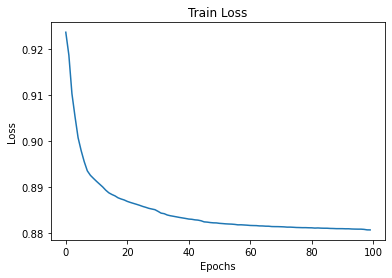

In [13]:
plt.figure()
plt.plot(train_loss)
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.savefig('deep_ae_mnist_loss.png')

# TLet's test the trained AutoEncoder

In [14]:
# test the network
test_image_reconstruction(net, testloader)

# Visualizing within diffetent steps

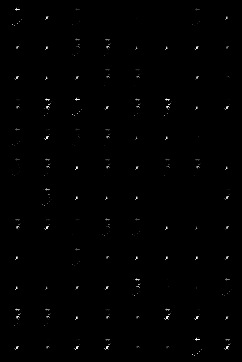

In [15]:
Image.open('./MNIST_Images/linear_ae_image0.png')

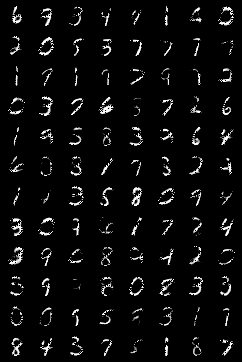

In [16]:
Image.open('./MNIST_Images/linear_ae_image50.png')

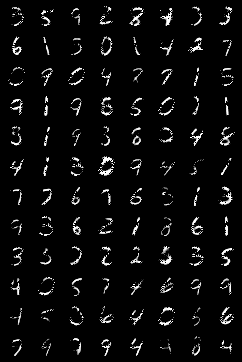

In [17]:
Image.open('./MNIST_Images/linear_ae_image95.png')

Visualizing the finally reconstructed images

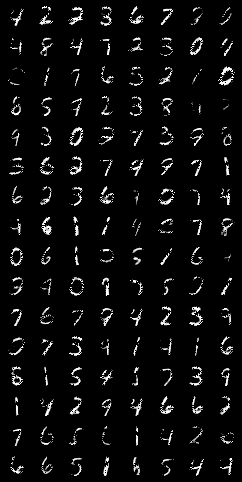

In [18]:
Image.open('./MNIST_reconstruction.png')